In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
class TrajectoryIndex:
    def __init__(self,traj_folder:Path,index_file:str|Path):
        self.traj_folder = traj_folder
        self.index_file = traj_folder/index_file
        index_df = pd.read_csv(self.index_file,index_col="index")
        self.files = index_df.to_dict(orient='index')

    def get(self,id:str):
        fname = self.files[id]['filename'] #because of annoying df.to_dict ugh
        traj_df = pd.read_csv(self.traj_folder/fname)
        t = np.array(traj_df['Timestep']); x = np.array(traj_df['Sample'])
        return t,x

    def __getitem__(self,id:str):
        return self.get(id)
        
def get_trajectories(traj_folder:str|Path,index_file:str|Path): return TrajectoryIndex(Path(traj_folder),index_file)

In [2]:
likelihood_folder = Path("../../likelihood_results/likelihoodv3/gaussian_1d")

diff_traj = get_trajectories(likelihood_folder/'3integrand_diff/trajectories','trajectory_index.csv')
flow_traj = get_trajectories(likelihood_folder/'3integrand_flow/trajectories','trajectory_index.csv')

In [3]:
from scipy.stats import norm
def get_prior_gaussian(x,sigma_max=70):
    return norm.pdf(x, loc=0, scale=sigma_max)
def get_gt_gaussian(x,mu1=-30, sigma1=8.0, w1=0.4, mu2=0, sigma2=5.0, w2=0.3, mu3=40, sigma3=10.0, w3=0.3):
    return w1 * norm.pdf(x, loc=mu1, scale=sigma1) + w2 * norm.pdf(x, loc=mu2, scale=sigma2) + w3 * norm.pdf(x, loc=mu3, scale=sigma3)

In [4]:
sample_ids = [1,25,24,100]
# sample_ids = range(1,100)[2::7]
sample_ids= [94,24,22,73]

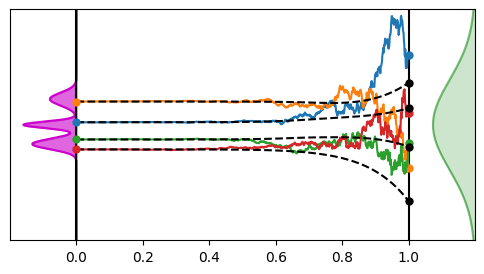

In [ ]:
import matplotlib.pyplot as plt
#composite both the trajectory and the distributions
vrange = (-180,180)

#first, plot trajectories
fig = plt.figure(figsize=(6,3))
# fig.size(6,2)?
# plt.set_aspect(0.75)
plt.xlim(-0.2,1.2)
plt.ylim(*vrange)
plt.xticks([0,0.2,0.4,0.6,0.8,1.0])
plt.yticks([])
diff = True
flow = True
onetraj = False
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for id,color in zip(sample_ids,colors):
    
    if diff:
        #plot endpoints
        ttraj,xtraj = diff_traj[id]
        plt.plot(ttraj[0],xtraj[0],'o',markersize=5,color=color,zorder=3)
        plt.plot(ttraj[-1],xtraj[-1],'o',markersize=5,color=color,zorder=1)
        plt.plot(ttraj,xtraj,zorder=1,color=color)#,color=(1.0,0.35,0.3))
    if flow:
        ttraj,xtraj = flow_traj[id-1]#I DON'T KNOW WHY THERE'S AN OFF BY ONE IN THE FLOW TRAJECTORIES AND IT'S FREAKING ME OUT???
        # plt.plot(ttraj[0],xtraj[0],'o',markersize=5,color='black',zorder=2)
        plt.plot(ttraj[-1],xtraj[-1],'o',markersize=5,color='black',zorder=2)
        plt.plot(ttraj,xtraj,label=id,linestyle='--',color='black',zorder=2) 
    if onetraj:
        break
# plt.legend()

#now for the vertical distributions
gt_max = 0.025*1.2
prior_max = 0.006*1.5 #1.5 adds padding
x = np.linspace(*vrange,10000)
prior_pdf = get_prior_gaussian(x)
gt_pdf = get_gt_gaussian(x)

plt.plot(-0.2*gt_pdf/gt_max,x,color=(0.8,0,0.8),zorder=0)
plt.fill_betweenx(x,-0.2*gt_pdf/gt_max,0,color=(0.8,0,0.8),alpha=0.6,zorder=0)
plt.plot(1.2-0.2*prior_pdf/prior_max,x,color='green',alpha=0.5,zorder=0)
plt.fill_betweenx(x,1.2-0.2*prior_pdf/prior_max,1.2,color='green',alpha=0.2,zorder=0)

#and dividing lines:
plt.plot([0,0],[*vrange],color='black',zorder=0)
plt.plot([1,1],[*vrange],color='black',zorder=0)

name = [['axonly','noflow'],['nodiff','all']][flow][diff]
if onetraj:
    name += "_onetraj"
# plt.savefig(f'eurocon_plots/trajectories_{name}.png',dpi=600)


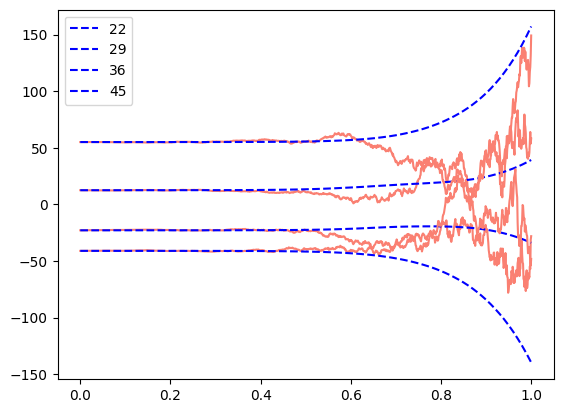

In [75]:
import matplotlib.pyplot as plt
for id in sample_ids:
    # plt.figure()
    plt.plot(*diff_traj[id],color='salmon')
    plt.plot(*flow_traj[id-1],label=id,color='blue',linestyle='--') #I DON'T KNOW WHY THERE'S AN OFF BY ONE IN THE FLOW TRAJECTORIES AND IT'S FREAKING ME OUT???
    # plt.ylim(-100,100)
    # plt.title(id)
plt.legend()

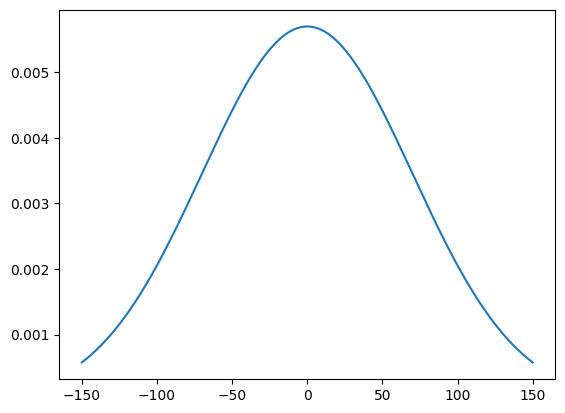